In [30]:
from __future__ import annotations
from helpers.env import ACTIONS
from helpers.env_ex import SlipperyGridWorldExtended
from helpers.rl import q_learning, sarsa, dyna_q, dyna_q_plus
from helpers.viz import plot_and_evaluate, plot_reward_comparison, evaluate
import numpy as np
import matplotlib.pyplot as plt

In [31]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [32]:
# =======================ADVANCED ENVIRONMENT CONFIGURATION====================== #
# |        Tune the dynamic world and learning settings from this block        | #
# ============================================================================ #

# Advanced environment parameters
dyna_rows = 10
dyna_cols = 15
dyna_start_state = (3, 3)
dyna_goal_state = (9, 12)
dyna_slip_prob = 0.2
random_seed = 987
dyna_step_reward = -1
dyna_goal_reward = 10
dyna_goal_move_frequency = 25
dyna_max_steps = 250

# Learning parameters
gamma = 0.99 # discount factor
dyna_alpha = 0.2
dyna_epsilon = 0.80
dyna_epsilon_min = 0.01
dyna_epsilon_decay = 0.9999

# Dyna sweep parameters
n_episodes_dyna_sweep = 4_000
n_episodes_dyna_convergence = 6_000
n_val_episodes_dyna = 30
dyna_planning_grid = [1, 5, 10, 20]
dyna_kappa_grid = [0.001, 0.01, 0.05]
dyna_plus_planning = 10


# Dyna-Q and Dyna-Q+

In [ ]:
def make_dyna_env():
    return SlipperyGridWorldExtended(
        rows=dyna_rows,
        cols=dyna_cols,
        start=dyna_start_state,
        goal=dyna_goal_state,
        slip_prob=dyna_slip_prob,
        step_reward=dyna_step_reward,
        goal_reward=dyna_goal_reward,
        max_steps=dyna_max_steps,
        seed=random_seed,
        goal_move_frequency=dyna_goal_move_frequency,
    )

def run_dyna_variant(trainer, *, n_episodes: int, **trainer_kwargs):
    train_env = make_dyna_env()
    Q, rewards = trainer(
        train_env,
        n_episodes=n_episodes,
        alpha=dyna_alpha,
        gamma=gamma,
        epsilon=dyna_epsilon,
        epsilon_min=dyna_epsilon_min,
        epsilon_decay=dyna_epsilon_decay,
        seed=random_seed,
        **trainer_kwargs,
    )
    metrics = evaluate(make_dyna_env(), Q=Q, n_episodes=n_val_episodes_dyna, seed=random_seed)
    return {"Q": Q, "rewards": rewards, "metrics": metrics}

dyna_q_results = {}
for n_planning in dyna_planning_grid:
    label = f"Dyna-Q (n={n_planning})"
    print(f"Running {label}...")
    dyna_q_results[label] = run_dyna_variant(
        dyna_q,
        n_episodes=n_episodes_dyna_sweep,
        n_planning=n_planning,
    )

dyna_q_plus_results = {}
for kappa in dyna_kappa_grid:
    label = f"Dyna-Q+ (kappa={kappa})"
    print(f"Running {label}...")
    dyna_q_plus_results[label] = run_dyna_variant(
        dyna_q_plus,
        n_episodes=n_episodes_dyna_sweep,
        n_planning=dyna_plus_planning,
        kappa=kappa,
    )

best_dyna_q_label = max(
    dyna_q_results,
    key=lambda label: dyna_q_results[label]["metrics"]["avg_return"],
 )
best_dyna_q_plus_label = max(
    dyna_q_plus_results,
    key=lambda label: dyna_q_plus_results[label]["metrics"]["avg_return"],
 )

best_dyna_q_rewards = dyna_q_results[best_dyna_q_label]["rewards"]
best_dyna_q_plus_rewards = dyna_q_plus_results[best_dyna_q_plus_label]["rewards"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, results, title, best_label in [
    (axes[0], dyna_q_results, "Dyna-Q planning sweep", best_dyna_q_label),
    (axes[1], dyna_q_plus_results, "Dyna-Q+ kappa sweep", best_dyna_q_plus_label),
]:
    labels = list(results.keys())
    avg_returns = [results[label]["metrics"]["avg_return"] for label in labels]
    colors = ["darkorange" if label == best_label else "steelblue" for label in labels]
    bars = ax.bar(labels, avg_returns, color=colors)
    ax.set_title(title)
    ax.set_ylabel("Average return")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(True, axis="y", alpha=0.2)
    for bar, value in zip(bars, avg_returns):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

print("Best Dyna-Q configuration:", best_dyna_q_label, dyna_q_results[best_dyna_q_label]["metrics"])
print("Best Dyna-Q+ configuration:", best_dyna_q_plus_label, dyna_q_plus_results[best_dyna_q_plus_label]["metrics"])

Running Dyna-Q (n=1)...
Running Dyna-Q (n=5)...
Running Dyna-Q (n=10)...
Running Dyna-Q (n=20)...


# Advanced environment convergence comparison

In [ ]:
ql_adv_env = make_dyna_env()
Q_ql_adv, rewards_ql_adv = q_learning(
    ql_adv_env,
    n_episodes=n_episodes_dyna_convergence,
    alpha=dyna_alpha,
    gamma=gamma,
    epsilon=dyna_epsilon,
    epsilon_min=dyna_epsilon_min,
    epsilon_decay=dyna_epsilon_decay,
    seed=random_seed,
 )

sarsa_adv_env = make_dyna_env()
Q_sarsa_adv, rewards_sarsa_adv = sarsa(
    sarsa_adv_env,
    n_episodes=n_episodes_dyna_convergence,
    alpha=dyna_alpha,
    gamma=gamma,
    epsilon=dyna_epsilon,
    epsilon_min=dyna_epsilon_min,
    epsilon_decay=dyna_epsilon_decay,
    seed=random_seed,
 )

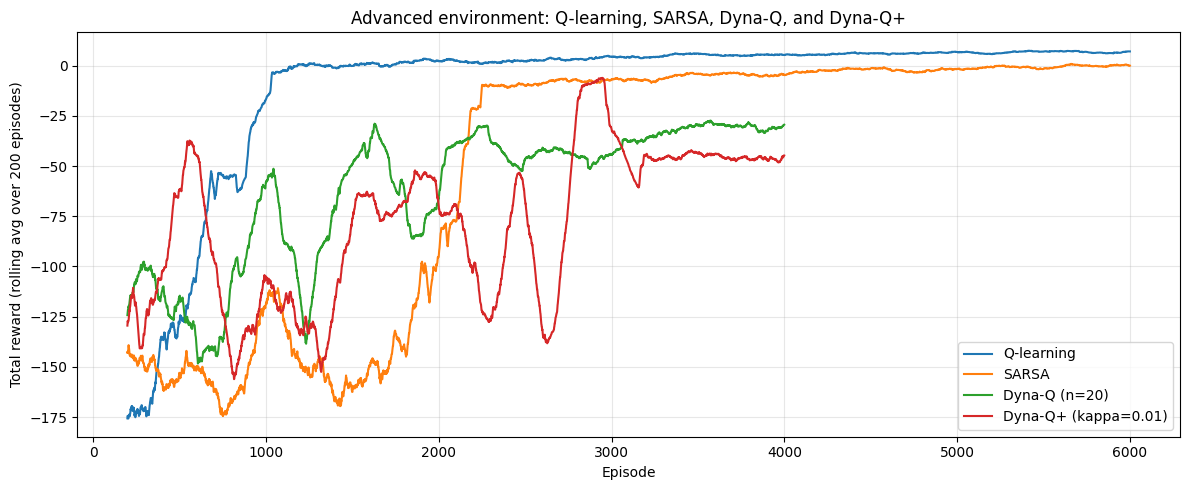

In [ ]:
plot_reward_comparison(
    {
        "Q-learning": rewards_ql_adv,
        "SARSA": rewards_sarsa_adv,
        best_dyna_q_label: best_dyna_q_rewards,
        best_dyna_q_plus_label: best_dyna_q_plus_rewards,
    },
    window=200,
    filename="convergence_dyna.png",
    title="Advanced environment: Q-learning, SARSA, Dyna-Q, and Dyna-Q+",
 )



# Model vs environment matrix

This section compares the same four selected agents across several extended-world configurations, so you can see which model is robust to goal motion, obstacle motion, and other environment changes.

In [ ]:
best_dyna_q_planning = int(best_dyna_q_label.split("n=")[1].rstrip(")"))
best_dyna_q_plus_kappa = float(best_dyna_q_plus_label.split("kappa=")[1].rstrip(")"))

n_episodes_env_matrix = 1_500
n_val_episodes_env_matrix = 30
convergence_window_env_matrix = 150

aux_goal_1 = (0, dyna_cols - 1)
aux_goal_2 = (dyna_rows - 1, 0)

if aux_goal_1 == dyna_start_state:
    aux_goal_1 = (0, max(0, dyna_cols - 2))
if aux_goal_2 == dyna_start_state:
    aux_goal_2 = (max(0, dyna_rows - 2), 0)

env_matrix_configs = [
    {
        "name": "Static goal, no obstacles",
        "kwargs": {
            "goal_move_frequency": None,
            "num_obstacles": 0,
            "obstacle_move_frequency": None,
        },
    },
    {
        "name": f"Moving goal every {dyna_goal_move_frequency} steps",
        "kwargs": {
            "goal_move_frequency": dyna_goal_move_frequency,
            "num_obstacles": 0,
            "obstacle_move_frequency": None,
        },
    },
    {
        "name": "Effectively static obstacles",
        "kwargs": {
            "goal_move_frequency": None,
            "num_obstacles": 5,
            "obstacle_move_frequency": 10_000,
            "obstacle_penalty": -5.0,
        },
    },
    {
        "name": "Moving goal + obstacles",
        "kwargs": {
            "goal_move_frequency": dyna_goal_move_frequency,
            "num_obstacles": 5,
            "obstacle_move_frequency": 25,
            "obstacle_penalty": -5.0,
        },
    },
    {
        "name": "Multiple goals, static",
        "kwargs": {
            "goal_move_frequency": None,
            "num_obstacles": 0,
            "obstacle_move_frequency": None,
            "goals_list": [dyna_goal_state, aux_goal_1, aux_goal_2],
            "goal_rewards": [dyna_goal_reward, dyna_goal_reward - 2, dyna_goal_reward - 2],
        },
    },
    {
        "name": "Multiple goals + moving obstacles",
        "kwargs": {
            "goal_move_frequency": None,
            "num_obstacles": 6,
            "obstacle_move_frequency": 20,
            "obstacle_penalty": -6.0,
            "goals_list": [dyna_goal_state, aux_goal_1, aux_goal_2],
            "goal_rewards": [dyna_goal_reward, dyna_goal_reward - 2, dyna_goal_reward - 2],
        },
    },
    {
        "name": "Multiple moving goals + moving obstacles",
        "kwargs": {
            "goal_move_frequency": dyna_goal_move_frequency,
            "num_obstacles": 6,
            "obstacle_move_frequency": 20,
            "obstacle_penalty": -6.0,
            "goals_list": [dyna_goal_state, aux_goal_1, aux_goal_2],
        },
    }
]


def make_env_variant(config, seed=None):
    return SlipperyGridWorldExtended(
        rows=dyna_rows,
        cols=dyna_cols,
        start=dyna_start_state,
        goal=dyna_goal_state,
        slip_prob=dyna_slip_prob,
        step_reward=dyna_step_reward,
        goal_reward=dyna_goal_reward,
        max_steps=dyna_max_steps,
        seed=random_seed if seed is None else seed,
        **config["kwargs"],
    )


model_specs = {
    "Q-learning": {
        "trainer": q_learning,
        "trainer_kwargs": {},
    },
    "SARSA": {
        "trainer": sarsa,
        "trainer_kwargs": {},
    },
    f"Dyna-Q (n={best_dyna_q_planning})": {
        "trainer": dyna_q,
        "trainer_kwargs": {
            "n_planning": best_dyna_q_planning,
        },
    },
    f"Dyna-Q+ (kappa={best_dyna_q_plus_kappa})": {
        "trainer": dyna_q_plus,
        "trainer_kwargs": {
            "n_planning": dyna_plus_planning,
            "kappa": best_dyna_q_plus_kappa,
        },
    },
}


def evaluate_with_terminal_check(env_factory, Q, n_episodes, seed):
    rng = np.random.default_rng(seed)
    returns = []
    steps = []
    success = []

    for _ in range(n_episodes):
        ep_seed = int(rng.integers(0, 1_000_000))
        env = env_factory(seed=ep_seed)
        state = env.reset()
        done = False
        total_reward = 0.0
        ep_steps = 0

        reached_goal = False
        while not done:
            action = int(np.argmax(Q[state]))
            state, reward, done, info = env.step(action)
            total_reward += float(reward)
            ep_steps += 1
            reached_goal = reached_goal or (info.get("reached_goal_idx") is not None)

        returns.append(total_reward)
        steps.append(ep_steps)
        success.append(1.0 if reached_goal else 0.0)

    return {
        "avg_return": float(np.round(np.mean(returns), decimals=4)),
        "std_return": float(np.round(np.std(returns), decimals=4)),
        "success_rate": float(np.round(np.mean(success), decimals=4)),
        "avg_steps": float(np.round(np.mean(steps), decimals=4)),
    }


def train_and_score_model(env_factory, trainer, trainer_kwargs):
    train_env = env_factory()
    Q, rewards = trainer(
        train_env,
        n_episodes=n_episodes_env_matrix,
        alpha=dyna_alpha,
        gamma=gamma,
        epsilon=dyna_epsilon,
        epsilon_min=dyna_epsilon_min,
        epsilon_decay=dyna_epsilon_decay,
        seed=random_seed,
        **trainer_kwargs,
    )
    metrics = evaluate_with_terminal_check(
        env_factory,
        Q=Q,
        n_episodes=n_val_episodes_env_matrix,
        seed=random_seed,
    )
    return {"Q": Q, "rewards": rewards, "metrics": metrics}


env_model_results = {}
env_reward_curves = {}
model_names = list(model_specs.keys())
env_names = [config["name"] for config in env_matrix_configs]
avg_return_matrix = np.zeros((len(env_matrix_configs), len(model_names)))
success_rate_matrix = np.zeros_like(avg_return_matrix)

for env_idx, env_config in enumerate(env_matrix_configs):
    env_name = env_config["name"]
    print(f"Running environment: {env_name}")

    def env_factory(seed=None, config=env_config):
        return make_env_variant(config, seed=seed)

    env_model_results[env_name] = {}
    env_reward_curves[env_name] = {}

    for model_idx, model_name in enumerate(model_names):
        print(f"  Training {model_name}...")
        spec = model_specs[model_name]
        result = train_and_score_model(
            env_factory,
            spec["trainer"],
            spec["trainer_kwargs"],
        )
        env_model_results[env_name][model_name] = result
        env_reward_curves[env_name][model_name] = result["rewards"]
        avg_return_matrix[env_idx, model_idx] = result["metrics"]["avg_return"]
        success_rate_matrix[env_idx, model_idx] = result["metrics"]["success_rate"]

best_models_by_env = []
for env_idx, env_name in enumerate(env_names):
    best_model_idx = max(
        range(len(model_names)),
        key=lambda idx: (
            success_rate_matrix[env_idx, idx],
            avg_return_matrix[env_idx, idx],
        ),
    )
    best_models_by_env.append(
        {
            "environment": env_name,
            "model": model_names[best_model_idx],
            "avg_return": float(avg_return_matrix[env_idx, best_model_idx]),
            "success_rate": float(success_rate_matrix[env_idx, best_model_idx]),
        }
    )

Running environment: Static goal, no obstacles
  Training Q-learning...
  Training SARSA...
  Training Dyna-Q (n=20)...
  Training Dyna-Q+ (kappa=0.01)...
Running environment: Moving goal every 25 steps
  Training Q-learning...
  Training SARSA...
  Training Dyna-Q (n=20)...
  Training Dyna-Q+ (kappa=0.01)...
Running environment: Effectively static obstacles
  Training Q-learning...
  Training SARSA...
  Training Dyna-Q (n=20)...
  Training Dyna-Q+ (kappa=0.01)...
Running environment: Moving goal + obstacles
  Training Q-learning...
  Training SARSA...
  Training Dyna-Q (n=20)...
  Training Dyna-Q+ (kappa=0.01)...
Running environment: Multiple goals, static
  Training Q-learning...
  Training SARSA...
  Training Dyna-Q (n=20)...
  Training Dyna-Q+ (kappa=0.01)...
Running environment: Multiple goals + moving obstacles
  Training Q-learning...
  Training SARSA...
  Training Dyna-Q (n=20)...
  Training Dyna-Q+ (kappa=0.01)...
Running environment: Multiple moving goals + moving obstacles
 

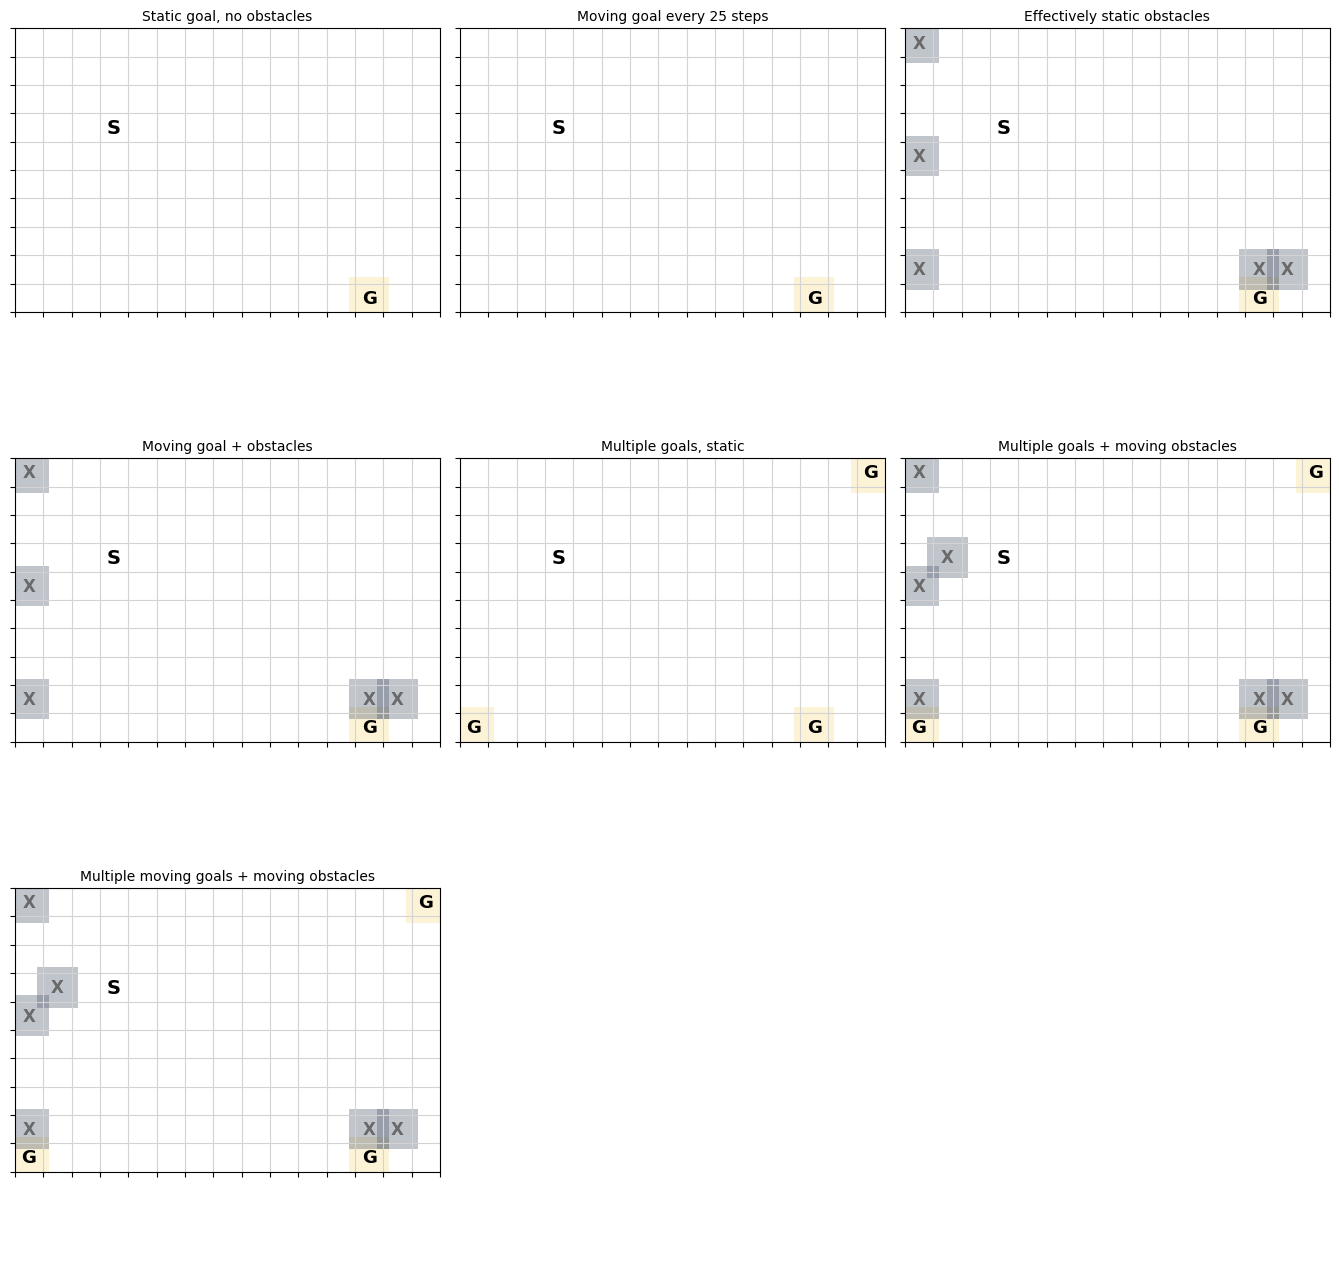

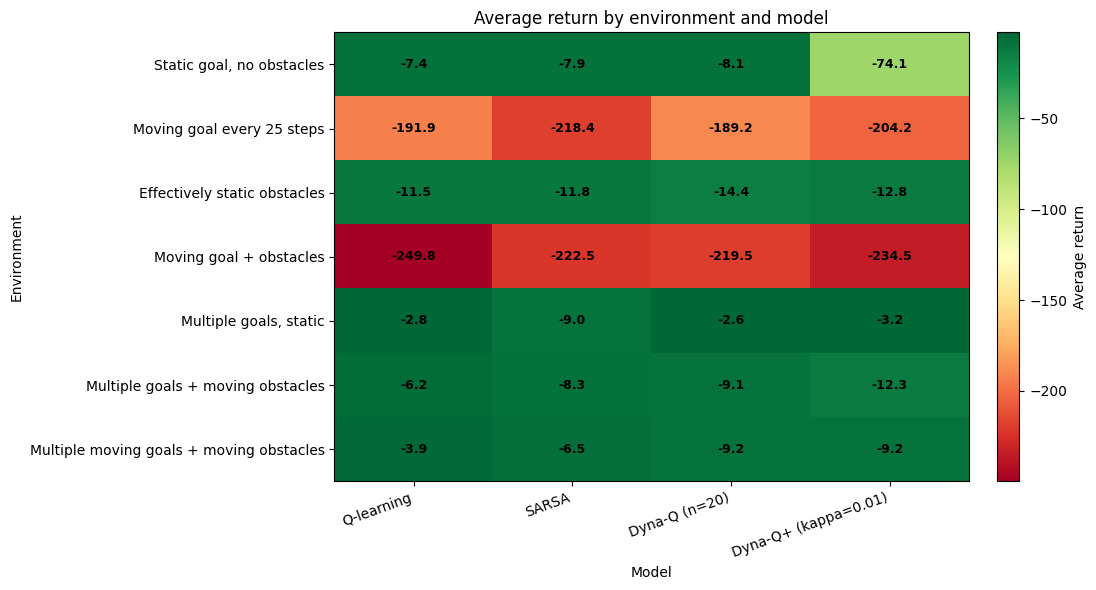

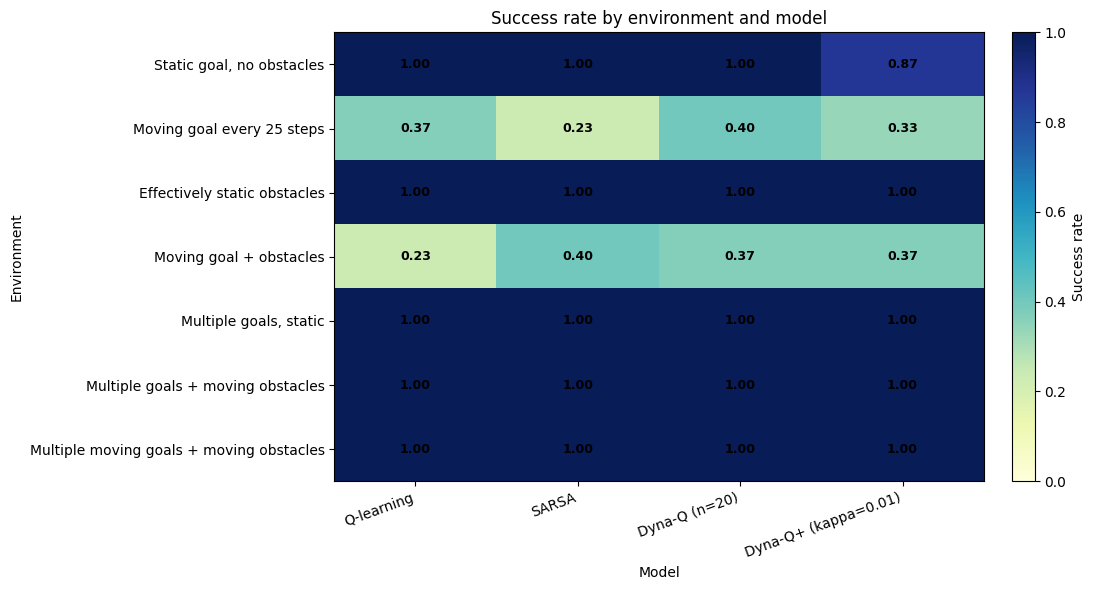

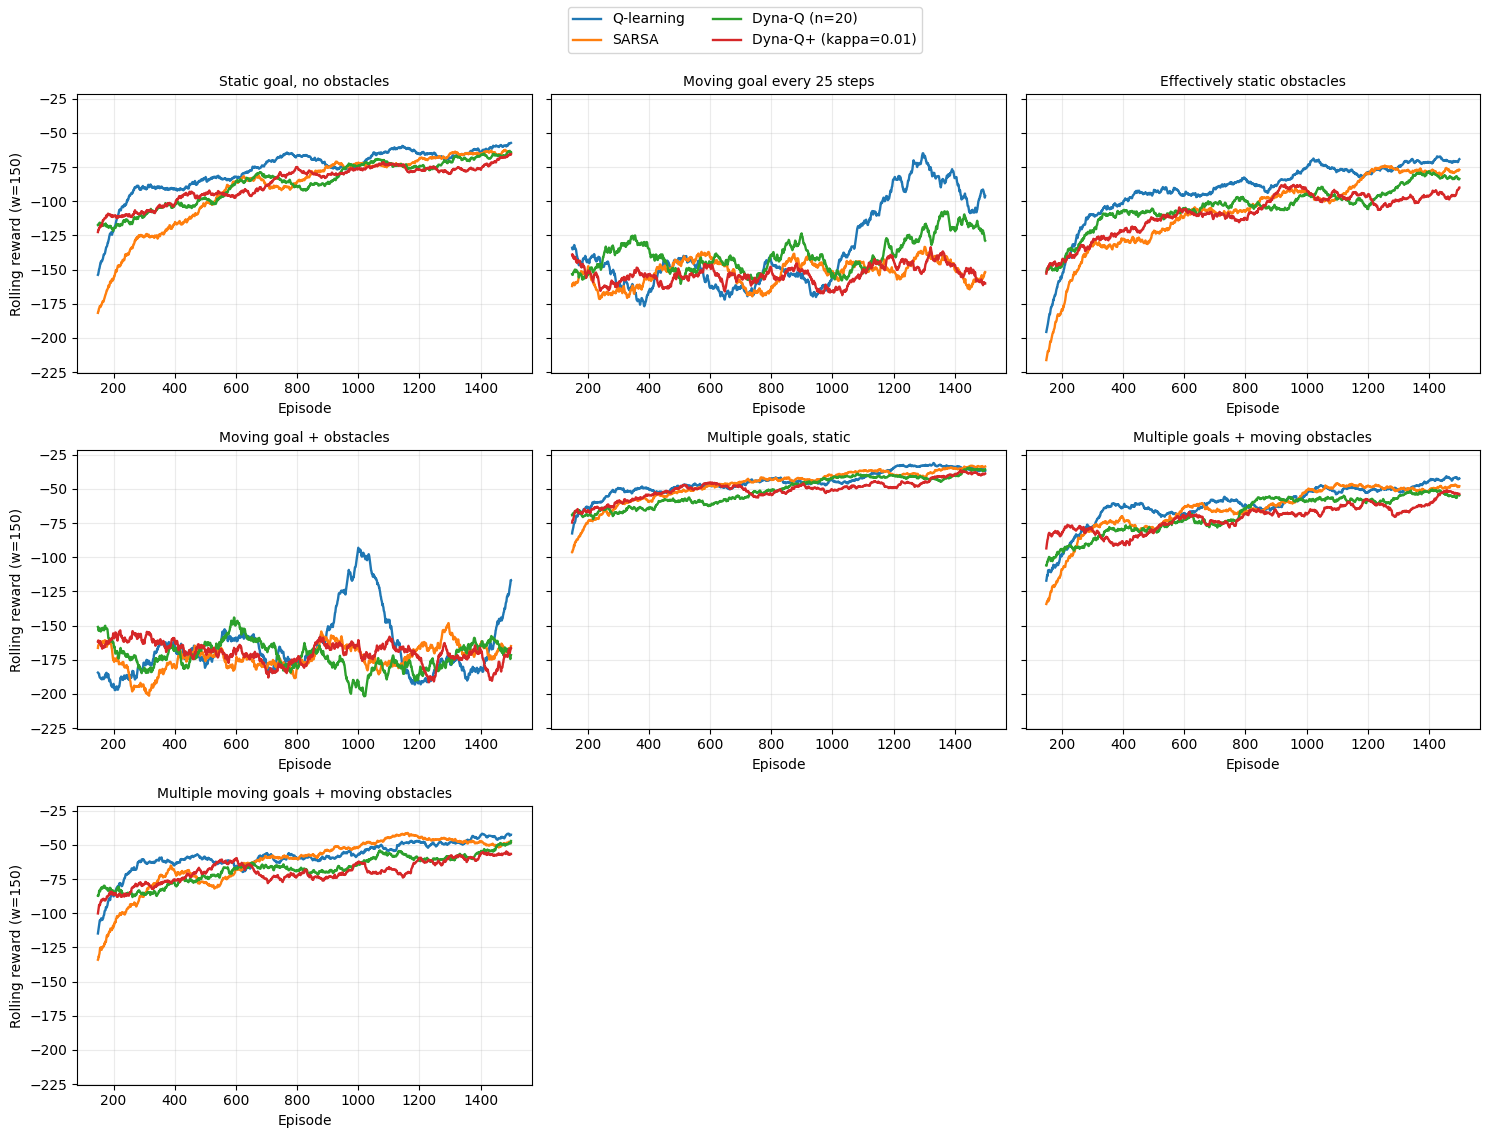

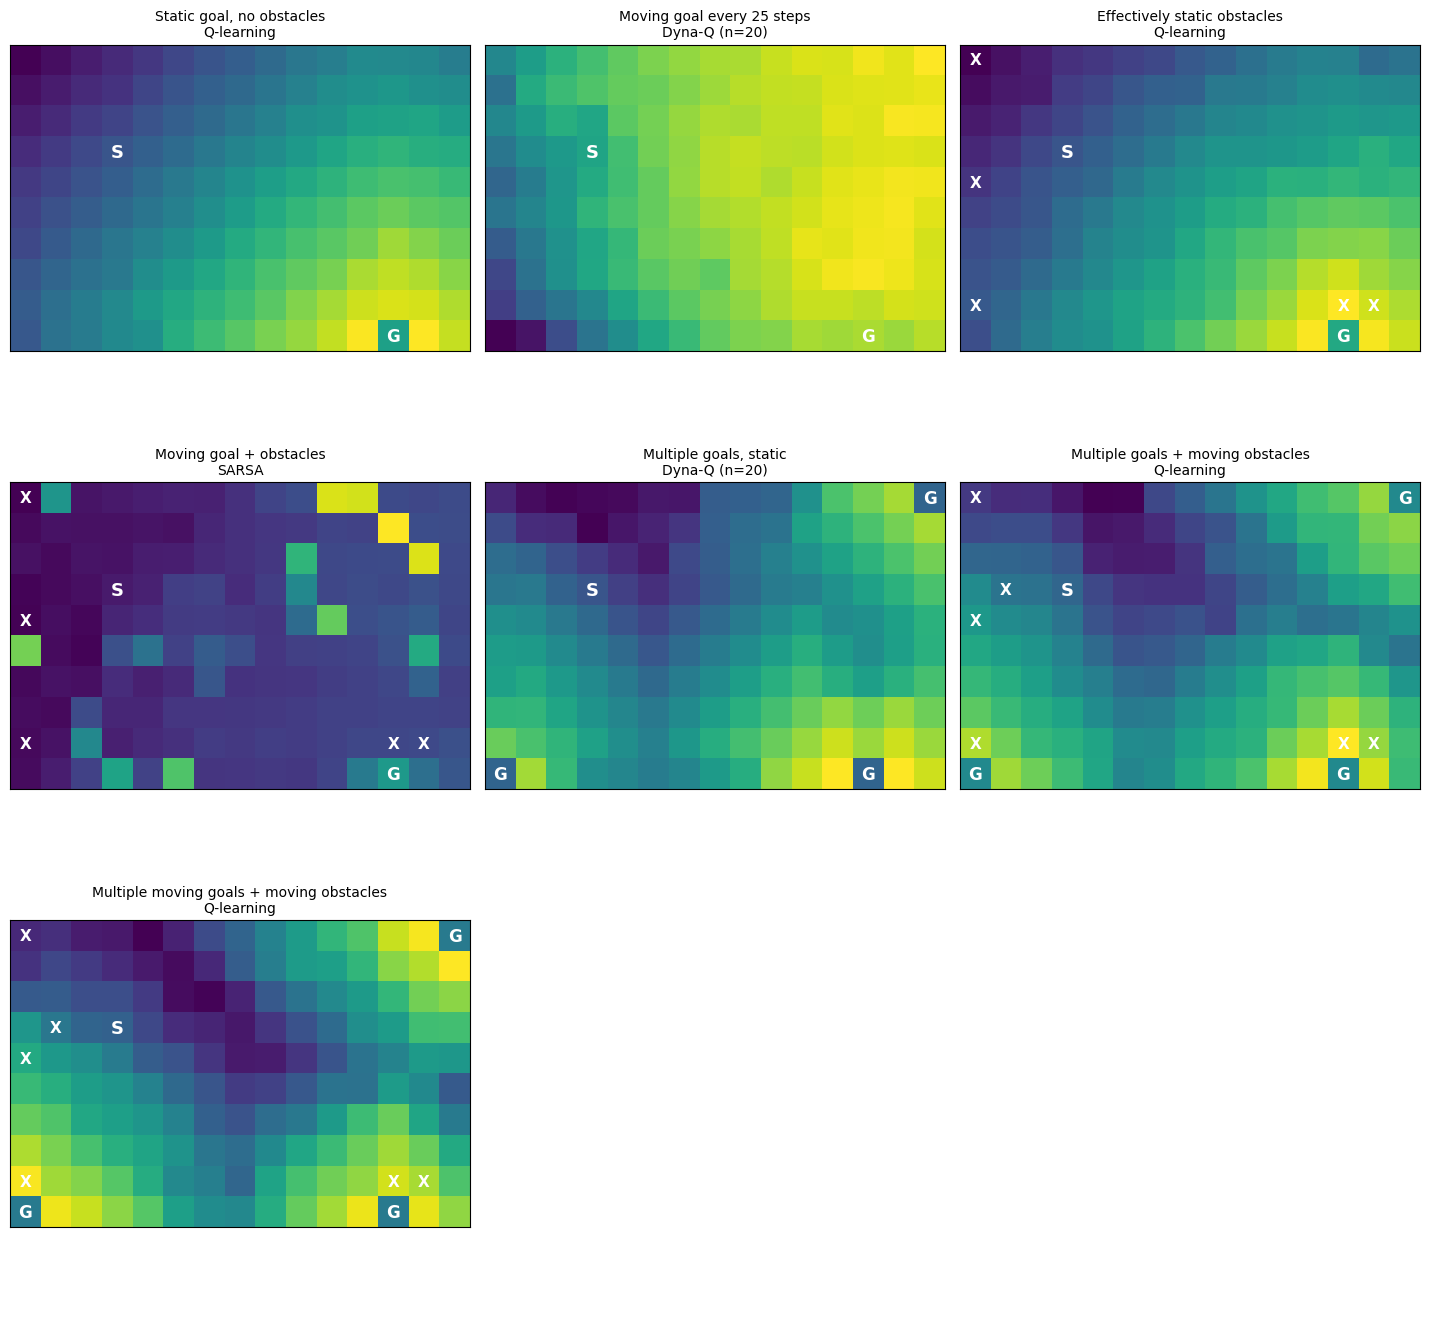

Best model per environment:
- Static goal, no obstacles: Q-learning (avg_return=-7.4, success_rate=1.00)
- Moving goal every 25 steps: Dyna-Q (n=20) (avg_return=-189.2, success_rate=0.40)
- Effectively static obstacles: Q-learning (avg_return=-11.5, success_rate=1.00)
- Moving goal + obstacles: SARSA (avg_return=-222.5, success_rate=0.40)
- Multiple goals, static: Dyna-Q (n=20) (avg_return=-2.6, success_rate=1.00)
- Multiple goals + moving obstacles: Q-learning (avg_return=-6.2, success_rate=1.00)
- Multiple moving goals + moving obstacles: Q-learning (avg_return=-3.9, success_rate=1.00)


In [ ]:
def draw_environment_layout(ax, env, title):
    ax.set_aspect("equal")
    ax.set_xlim(-0.5, env.cols - 0.5)
    ax.set_ylim(env.rows - 0.5, -0.5)
    ax.set_xticks(np.arange(-0.5, env.cols, 1))
    ax.set_yticks(np.arange(-0.5, env.rows, 1))
    ax.grid(True, color="lightgray", linewidth=0.8)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(title, fontsize=10)

    start_row, start_col = env.start_row_column
    ax.text(start_col, start_row, "S", ha="center", va="center", fontsize=14, fontweight="bold")

    goals = getattr(env, "goals", None) or [env.goal_row_column]
    for goal_row, goal_col in goals:
        ax.scatter(goal_col, goal_row, marker="s", s=850, color="#f4d35e", alpha=0.25, edgecolors="none")
        ax.text(goal_col, goal_row, "G", ha="center", va="center", fontsize=13, fontweight="bold")

    obstacles = getattr(env, "obstacles", None) or []
    for obstacle_row, obstacle_col in obstacles:
        ax.scatter(obstacle_col, obstacle_row, marker="s", s=850, color="#4c566a", alpha=0.35, edgecolors="none")
        ax.text(obstacle_col, obstacle_row, "X", ha="center", va="center", fontsize=12, fontweight="bold", color="dimgray")


def plot_score_matrix(matrix, title, cmap, colorbar_label, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(11, 6))
    im = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(model_names)))
    ax.set_xticklabels(model_names, rotation=20, ha="right")
    ax.set_yticks(np.arange(len(env_names)))
    ax.set_yticklabels(env_names)
    ax.set_xlabel("Model")
    ax.set_ylabel("Environment")
    ax.set_title(title)

    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            cell_text = f"{matrix[row_idx, col_idx]:.2f}" if vmax == 1 else f"{matrix[row_idx, col_idx]:.1f}"
            ax.text(
                col_idx,
                row_idx,
                cell_text,
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="black",
            )

    fig.colorbar(im, ax=ax, label=colorbar_label, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_convergence_grid(reward_curves_by_env, window):
    n_envs = len(env_names)
    n_cols = int(np.ceil(np.sqrt(n_envs)))
    n_rows = int(np.ceil(n_envs / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows), sharey=True)
    flat_axes = np.array(axes).reshape(-1)

    for idx, env_name in enumerate(env_names):
        ax = flat_axes[idx]
        curves = reward_curves_by_env[env_name]
        for model_name in model_names:
            rewards = curves[model_name]
            if len(rewards) < window:
                continue
            smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")
            episodes = np.arange(window - 1, window - 1 + len(smoothed))
            ax.plot(episodes, smoothed, label=model_name, linewidth=1.7)

        ax.set_title(env_name, fontsize=10)
        ax.set_xlabel("Episode")
        ax.grid(True, alpha=0.25)
        if idx % n_cols == 0:
            ax.set_ylabel(f"Rolling reward (w={window})")

    for idx in range(n_envs, len(flat_axes)):
        flat_axes[idx].axis("off")

    handles, labels = flat_axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def draw_value_heatmap(ax, env, values, title):
    value_grid = values.reshape(env.rows, env.cols)
    im = ax.imshow(value_grid, cmap="viridis")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

    start_row, start_col = env.start_row_column
    ax.text(start_col, start_row, "S", ha="center", va="center", fontsize=13, fontweight="bold", color="white")

    goals = getattr(env, "goals", None) or [env.goal_row_column]
    for goal_row, goal_col in goals:
        ax.text(goal_col, goal_row, "G", ha="center", va="center", fontsize=12, fontweight="bold", color="white")

    obstacles = getattr(env, "obstacles", None) or []
    for obstacle_row, obstacle_col in obstacles:
        ax.text(obstacle_col, obstacle_row, "X", ha="center", va="center", fontsize=11, fontweight="bold", color="white")

    return im


def plot_best_model_value_heatmaps():
    n_envs_local = len(env_names)
    n_cols_local = int(np.ceil(np.sqrt(n_envs_local)))
    n_rows_local = int(np.ceil(n_envs_local / n_cols_local))
    fig, axes = plt.subplots(n_rows_local, n_cols_local, figsize=(4.8 * n_cols_local, 4.8 * n_rows_local))
    flat_axes_local = np.array(axes).reshape(-1)
    heatmap_images = []

    for idx, env_config in enumerate(env_matrix_configs):
        env_name = env_config["name"]
        best_model_name = best_models_by_env[idx]["model"]
        best_q = env_model_results[env_name][best_model_name]["Q"]
        best_env = make_env_variant(env_config)
        heatmap = draw_value_heatmap(flat_axes_local[idx], best_env, np.max(best_q, axis=1), f"{env_name}\n{best_model_name}")
        heatmap_images.append(heatmap)

    for idx in range(n_envs_local, len(flat_axes_local)):
        flat_axes_local[idx].axis("off")

    #fig.colorbar(heatmap_images[0], ax=flat_axes_local[:n_envs_local].tolist(), fraction=0.03, pad=0.02)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


n_envs = len(env_matrix_configs)
layout_cols = int(np.ceil(np.sqrt(n_envs)))
layout_rows = int(np.ceil(n_envs / layout_cols))

fig, axes = plt.subplots(layout_rows, layout_cols, figsize=(4.5 * layout_cols, 4.5 * layout_rows))
flat_axes = np.array(axes).reshape(-1)
for idx, env_config in enumerate(env_matrix_configs):
    draw_environment_layout(flat_axes[idx], make_env_variant(env_config), env_config["name"])
for idx in range(n_envs, len(flat_axes)):
    flat_axes[idx].axis("off")
plt.tight_layout()
plt.show()

plot_score_matrix(
    avg_return_matrix,
    title="Average return by environment and model",
    cmap="RdYlGn",
    colorbar_label="Average return",
)

plot_score_matrix(
    success_rate_matrix,
    title="Success rate by environment and model",
    cmap="YlGnBu",
    colorbar_label="Success rate",
    vmin=0,
    vmax=1,
)

plot_convergence_grid(env_reward_curves, window=convergence_window_env_matrix)
plot_best_model_value_heatmaps()

print("Best model per environment:")
for summary in best_models_by_env:
    print(
        f"- {summary['environment']}: {summary['model']} "
        f"(avg_return={summary['avg_return']:.1f}, success_rate={summary['success_rate']:.2f})"
    )